In [36]:
# This project aims to compare the performance of two machine learning models (Model_1 and Model_2)
# in forecasting future electricity consumption. The goal is to identify 
# which model produces more accurate predictions.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Lasso


***CLEANING***

In [11]:
# Load the dataset
df = pd.read_csv('Econ425.csv')
# Display missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
hh_id              0
year               0
month              0
zipcode         1610
control            0
treatment         20
lusage             0
luse1          11270
luse2           7010
luse3           6320
luse4           6350
luse5           6330
luse6           6250
children        1610
hhsize2            0
hhsize3            0
hhsize4            0
hhsize5            0
hhsize5plus        0
income2         1610
income3         1610
income4         1610
income5         1610
income6         1610
income7         1610
income8         1610
income9         1610
owner           1610
dtype: int64


In [13]:
# Handle missing values for categorical columns using mode
cat_cols = ["zipcode", "treatment", "income2", "income3", "income4", "income5", 
            "income6", "income7", "income8", "income9", "owner", 'children']
for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

In [15]:
# Handle missing values for numeric columns using median
numeric_cols = ["luse1", "luse2", "luse3", "luse4", "luse5", "luse6"]
medians = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(medians)

In [17]:
# Display missing values after cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
hh_id          0
year           0
month          0
zipcode        0
control        0
treatment      0
lusage         0
luse1          0
luse2          0
luse3          0
luse4          0
luse5          0
luse6          0
children       0
hhsize2        0
hhsize3        0
hhsize4        0
hhsize5        0
hhsize5plus    0
income2        0
income3        0
income4        0
income5        0
income6        0
income7        0
income8        0
income9        0
owner          0
dtype: int64


In [19]:
# Data exploration: summary statistics and data types
print("Dataset summary:")
print(df.describe())
print("Data types:")
print(df.dtypes)

Dataset summary:
               hh_id           year          month        zipcode  \
count  234560.000000  234560.000000  234560.000000  234560.000000   
mean    23662.523192    2010.500000       6.000000      38.424625   
std     13696.141627       0.500001       1.414217      19.289706   
min         3.000000    2010.000000       4.000000       1.000000   
25%     11790.750000    2010.000000       5.000000      28.000000   
50%     23735.000000    2010.500000       6.000000      42.000000   
75%     35526.500000    2011.000000       7.000000      54.000000   
max     47356.000000    2011.000000       8.000000      76.000000   

             control      treatment         lusage          luse1  \
count  234560.000000  234560.000000  234560.000000  234560.000000   
mean        0.796513       0.203402       6.368214       6.110244   
std         0.402593       0.402530       0.627374       0.569293   
min         0.000000       0.000000       3.914090      -0.200671   
25%         1.00

In [21]:
# Detect outliers using the Interquartile Range (IQR) method
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("\nOutliers Detected:")
print(outliers)


Outliers Detected:
hh_id              0
year               0
month              0
zipcode            0
control        47730
treatment      47710
lusage          1944
luse1           2870
luse2           2370
luse3           2330
luse4           2660
luse5           3600
luse6           2560
children           0
hhsize2            0
hhsize3        56180
hhsize4        36200
hhsize5        19990
hhsize5plus    14480
income2        12270
income3        21830
income4        26560
income5        29070
income6            0
income7        31130
income8        12540
income9         7100
owner          38410
dtype: int64


In [23]:
# I decided not to eliminate outliers since the most inmportant features like 'luse1-6' and 'lusage' are 
# in log transformed form already.
# Any attempt to eliminate the outliers created a lot of NA values on my end. 

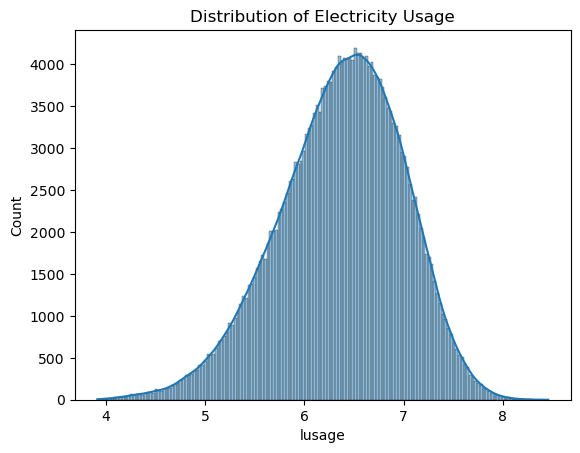

In [25]:
# Visualization: distribution of electricity consumption (example)
sns.histplot(data=df, x='lusage', kde=True)
plt.title('Distribution of Electricity Usage')
plt.show()

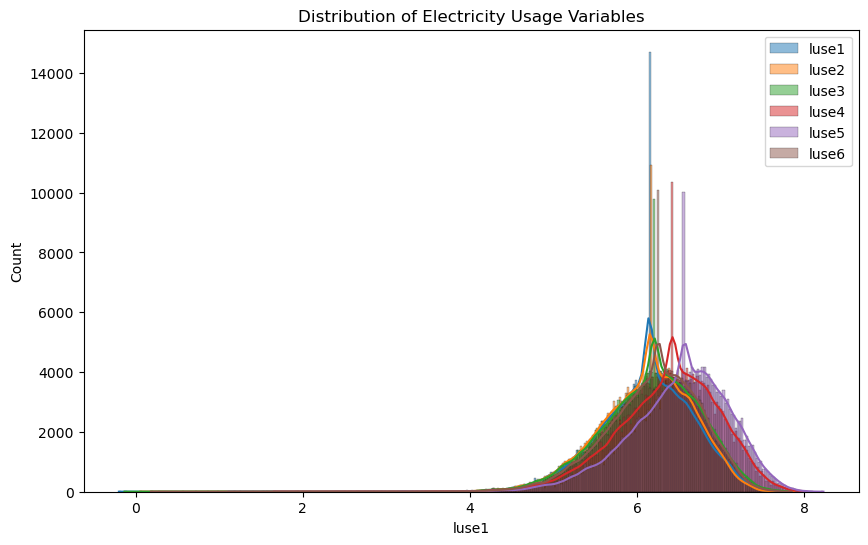

In [27]:
plt.figure(figsize=(10, 6))
for col in numeric_cols:
    sns.histplot(df[col], kde=True, label=col, alpha=0.5)

plt.title('Distribution of Electricity Usage Variables')
plt.legend()
plt.show()

In [28]:
# Calculate the correlation matrix to analyze relationships between variables
correlation_matrix = df.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                    hh_id          year         month       zipcode  \
hh_id        1.000000e+00 -1.095104e-11  4.677312e-15  6.117365e-04   
year        -1.095104e-11  1.000000e+00 -2.802243e-16 -4.423253e-14   
month        4.677312e-15 -2.802243e-16  1.000000e+00  1.484100e-16   
zipcode      6.117365e-04 -4.423253e-14  1.484100e-16  1.000000e+00   
control     -9.328158e-04 -1.783009e-14 -1.153099e-16  1.541174e-03   
treatment    8.400490e-04  1.860559e-14  1.136082e-16 -1.580677e-03   
lusage       8.310836e-03 -2.196434e-02  2.673258e-01 -3.168963e-02   
luse1        1.609161e-03  9.045551e-14  5.700129e-17 -2.342163e-02   
luse2        6.054924e-03  2.567794e-14 -3.327722e-18 -2.496248e-02   
luse3        9.147481e-03  4.586557e-14 -2.420144e-18 -4.464672e-02   
luse4        1.042266e-02  2.648742e-14 -3.325379e-17 -4.176115e-02   
luse5        1.135649e-02 -1.631036e-14 -5.723963e-17 -3.425699e-02   
luse6        8.025109e-03  8.537265e-16  7.023188e-18 -3

The variable treatment has positive coefficients across all three models, suggesting that households in the treatment group tend to have slightly higher income or ownership probability. Income categories (income2–income7) generally have negative coefficients, indicating an inverse relationship with higher income brackets. Household size (hhsize2–hhsize5plus) shows mixed effects, with larger households tending to be associated with increased ownership. The diagonal values of 1.000 for income8, income9, and owner indicate that these variables are perfectly correlated with themselves.

***MODEL BUILDING & TRAINING***

***Gradientboosting***

In [34]:
# Filter control group data for training models
control_group = df[df['control'] == 1]

# Define features and target variable for 2010 data (predicting 2011 consumption)
X_control = control_group[[
    "luse1", "luse2", "luse3", "luse4", "luse5", "luse6",
    'income2', 'income3', 'income4', 'income5', 'income6', 'income7', 'income8',
    'owner', 'children', 'zipcode', 'hhsize2', 'hhsize3', 'hhsize4', 'hhsize5'
]]
y_control = control_group["lusage"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_control, y_control, test_size=0.2, random_state=42)

# Gradient Boosting Regressor
gbr_reg = GradientBoostingRegressor(
    n_estimators=100,        # Number of boosting stages
    learning_rate=0.1,       # Shrinks contribution of each tree
    max_depth=3,             # Maximum depth of trees
    random_state=42          # Ensures reproducibility
)

# Train the model
gbr_reg.fit(X_train, y_train)

# Predict on test set
y_pred_gbr = gbr_reg.predict(X_test)

# Evaluate model performance
print("Gradient Boosting Regressor Performance:")
print(f"MSE: {mean_squared_error(y_test, y_pred_gbr):.4f}")
print(f"R²: {r2_score(y_test, y_pred_gbr):.4f}")


Gradient Boosting Regressor Performance:
MSE: 0.1295
R²: 0.6785


The Gradient Boosting Regressor demonstrates solid predictive performance, with a **Mean Squared Error (MSE) of 0.1295**, indicating a relatively low average error in predictions. The **R² value of 0.6785** suggests that approximately **67.85% of the variance** in the target variable is explained by the model, showcasing a strong fit. While the model captures most of the underlying patterns in the data, there is still room for improvement, possibly through hyperparameter tuning or feature engineering.

***LASSO***

In [38]:
# LASSO model
lasso_reg = Lasso(
    alpha=0.1,               # Regularization strength (larger value means stronger regularization)
    random_state=42          # Ensures reproducibility
)

# Train the model
lasso_reg.fit(X_train, y_train)

# Predict on test set
y_pred_lasso = lasso_reg.predict(X_test)

# Evaluate model performance
print("LASSO Model Performance:")
print(f"MSE: {mean_squared_error(y_test, y_pred_lasso):.4f}")
print(f"R²: {r2_score(y_test, y_pred_lasso):.4f}")


LASSO Model Performance:
MSE: 0.1705
R²: 0.5767


The LASSO (Least Absolute Shrinkage and Selection Operator) model exhibits a **Mean Squared Error (MSE) of 0.1705**, indicating a higher average prediction error compared to the Gradient Boosting Regressor. The **R² value of 0.5767** suggests that the model explains **57.67% of the variance** in the target variable, which is lower than the Gradient Boosting model's performance. This implies that while LASSO is effective in feature selection and reducing overfitting, it may have underfit the data or discarded some useful predictors. Further tuning of the regularization parameter (alpha) could help improve its predictive accuracy.

In [41]:
# Step 3: Predictions (Treatment Group)

# Filter treatment group data for predictions
treatment_group = df[df['treatment'] == 1]

# Check if the treatment group is empty
if treatment_group.empty:
    print("No data found for the treatment group (treatment == 1).")
else:
    X_treatment = treatment_group[["luse1", "luse2", "luse3", "luse4", "luse5", "luse6",
        'income2', 'income3', 'income4', 'income5', 'income6', 'income7', 'income8',
        'owner', 'children', 'zipcode', 'hhsize2', 'hhsize3', 'hhsize4', 'hhsize5']]

    # Make predictions using both models for treatment group households in 2011
    treatment_predictions_1 = gbr_reg.predict(X_treatment)
    treatment_predictions_2 = lasso_reg.predict(X_treatment)


***PREDICTIONS AND EVALAUTION***

In [44]:
# Step 3: Predictions (Treatment Group)

# Filter treatment group data for predictions
treatment_group = df[df['treatment'] == 1]
X_treatment = treatment_group[["luse1", "luse2", "luse3", "luse4", "luse5", "luse6",
    'income2', 'income3', 'income4', 'income5', 'income6', 'income7', 'income8',
    'owner', 'children', 'zipcode', 'hhsize2', 'hhsize3', 'hhsize4', 'hhsize5']]

# Make predictions using both models for treatment group households in 2011
treatment_predictions_1 = gbr_reg.predict(X_treatment)
treatment_predictions_2 = lasso_reg.predict(X_treatment)

In [46]:
# Actual values of consumption for treatment group in 2011
actual_values_treatment = treatment_group["lusage"]

# Calculate evaluation metrics for both models
mse_model_1 = mean_squared_error(actual_values_treatment, treatment_predictions_1)
mae_model_1 = mean_absolute_error(actual_values_treatment, treatment_predictions_1)
r2_model_1 = r2_score(actual_values_treatment, treatment_predictions_1)

mse_model_2 = mean_squared_error(actual_values_treatment, treatment_predictions_2)
mae_model_2 = mean_absolute_error(actual_values_treatment, treatment_predictions_2)
r2_model_2 = r2_score(actual_values_treatment, treatment_predictions_2)

# Print evaluation results
print("Evaluation on Treatment Group (Model 1 - GBR):")
print(f"MSE: {mse_model_1:.4f}")
print(f"MAE: {mae_model_1:.4f}")
print(f"R²: {r2_model_1:.4f}")

print("Evaluation on Treatment Group (Model 2 - Lasso):")
print(f"MSE: {mse_model_2:.4f}")
print(f"MAE: {mae_model_2:.4f}")
print(f"R²: {r2_model_2:.4f}")

Evaluation on Treatment Group (Model 1 - GBR):
MSE: 0.1230
MAE: 0.2690
R²: 0.6627
Evaluation on Treatment Group (Model 2 - Lasso):
MSE: 0.1562
MAE: 0.3138
R²: 0.5717


The evaluation of the treatment group reveals that **Model 1 (Gradient Boosting Regressor)** outperforms **Model 2 (LASSO)** across all metrics. The **MSE of 0.1230** and **MAE of 0.2690** indicate that GBR has lower prediction errors, while an **R² of 0.6627** suggests it explains **66.27% of the variance** in the treatment group. In contrast, **LASSO (Model 2)** has a **higher MSE (0.1562) and MAE (0.3138)**, indicating greater prediction errors, and a lower **R² of 0.5717**, meaning it captures less of the variance. These results suggest that GBR is better suited for predicting outcomes within the treatment group, likely due to its ability to capture complex nonlinear relationships.

In [49]:
# Create a comparison DataFrame for actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual': actual_values_treatment,
    'Predicted_Model_1': treatment_predictions_1,
    'Predicted_Model_2': treatment_predictions_2
})

comparison_df.head()

,Actual,Predicted_Model_1,Predicted_Model_2
0,6.322805,6.543146,6.447189
1,6.510683,6.543146,6.447189
2,6.696693,6.543146,6.447189
3,6.967286,6.543146,6.447189
4,6.966908,6.543146,6.447189


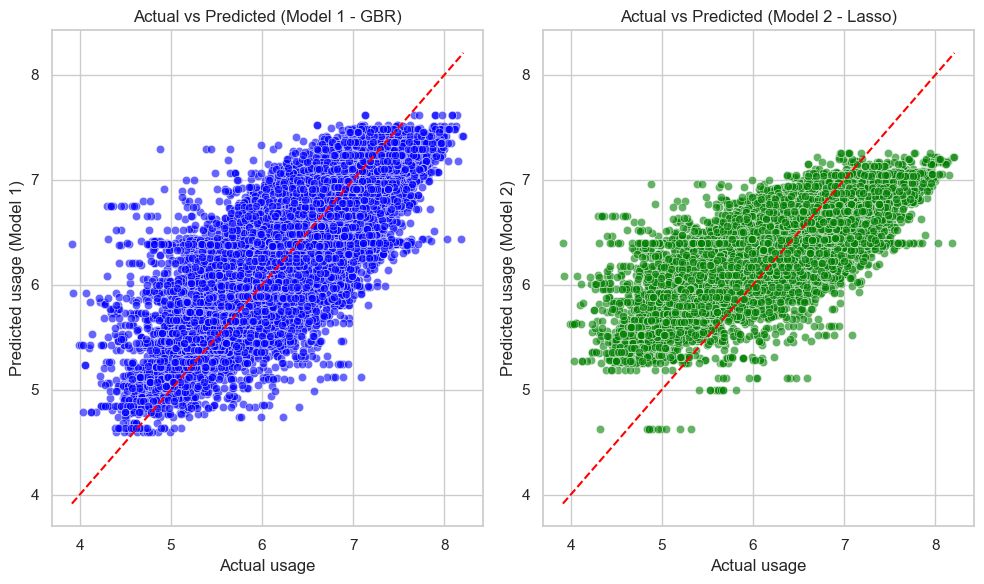

In [51]:
# Set the plot size and style
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Plot Actual vs Predicted values for Model 1
plt.subplot(1, 2, 1)
sns.scatterplot(x=comparison_df['Actual'], y=comparison_df['Predicted_Model_1'], color='blue', alpha=0.6)
plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()],
         [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
         linestyle='--', color='red')  # Line of perfect prediction
plt.title('Actual vs Predicted (Model 1 - GBR)')
plt.xlabel('Actual usage')
plt.ylabel('Predicted usage (Model 1)')

# Plot Actual vs Predicted values for Model 2
plt.subplot(1, 2, 2)
sns.scatterplot(x=comparison_df['Actual'], y=comparison_df['Predicted_Model_2'], color='green', alpha=0.6)
plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()],
         [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
         linestyle='--', color='red')  # Line of perfect prediction
plt.title('Actual vs Predicted (Model 2 - Lasso)')
plt.xlabel('Actual usage')
plt.ylabel('Predicted usage (Model 2)')

# Show the plots
plt.tight_layout()
plt.show()


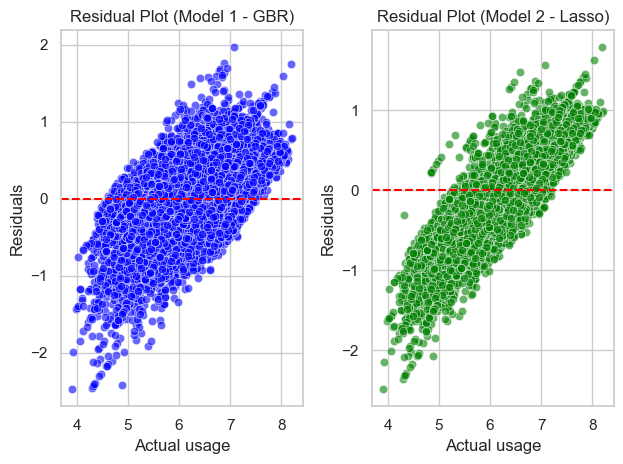

In [53]:
# Plot Residuals for Model 1 (GBR)
plt.subplot(1, 2, 1)
residuals_1 = comparison_df['Actual'] - comparison_df['Predicted_Model_1']
sns.scatterplot(x=comparison_df['Actual'], y=residuals_1, color='blue', alpha=0.6)
plt.axhline(0, linestyle='--', color='red')  # Zero residual line
plt.title('Residual Plot (Model 1 - GBR)')
plt.xlabel('Actual usage')
plt.ylabel('Residuals')

# Plot Residuals for Model 2 (Lasso)
plt.subplot(1, 2, 2)
residuals_2 = comparison_df['Actual'] - comparison_df['Predicted_Model_2']
sns.scatterplot(x=comparison_df['Actual'], y=residuals_2, color='green', alpha=0.6)
plt.axhline(0, linestyle='--', color='red')  # Zero residual line
plt.title('Residual Plot (Model 2 - Lasso)')
plt.xlabel('Actual usage')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()


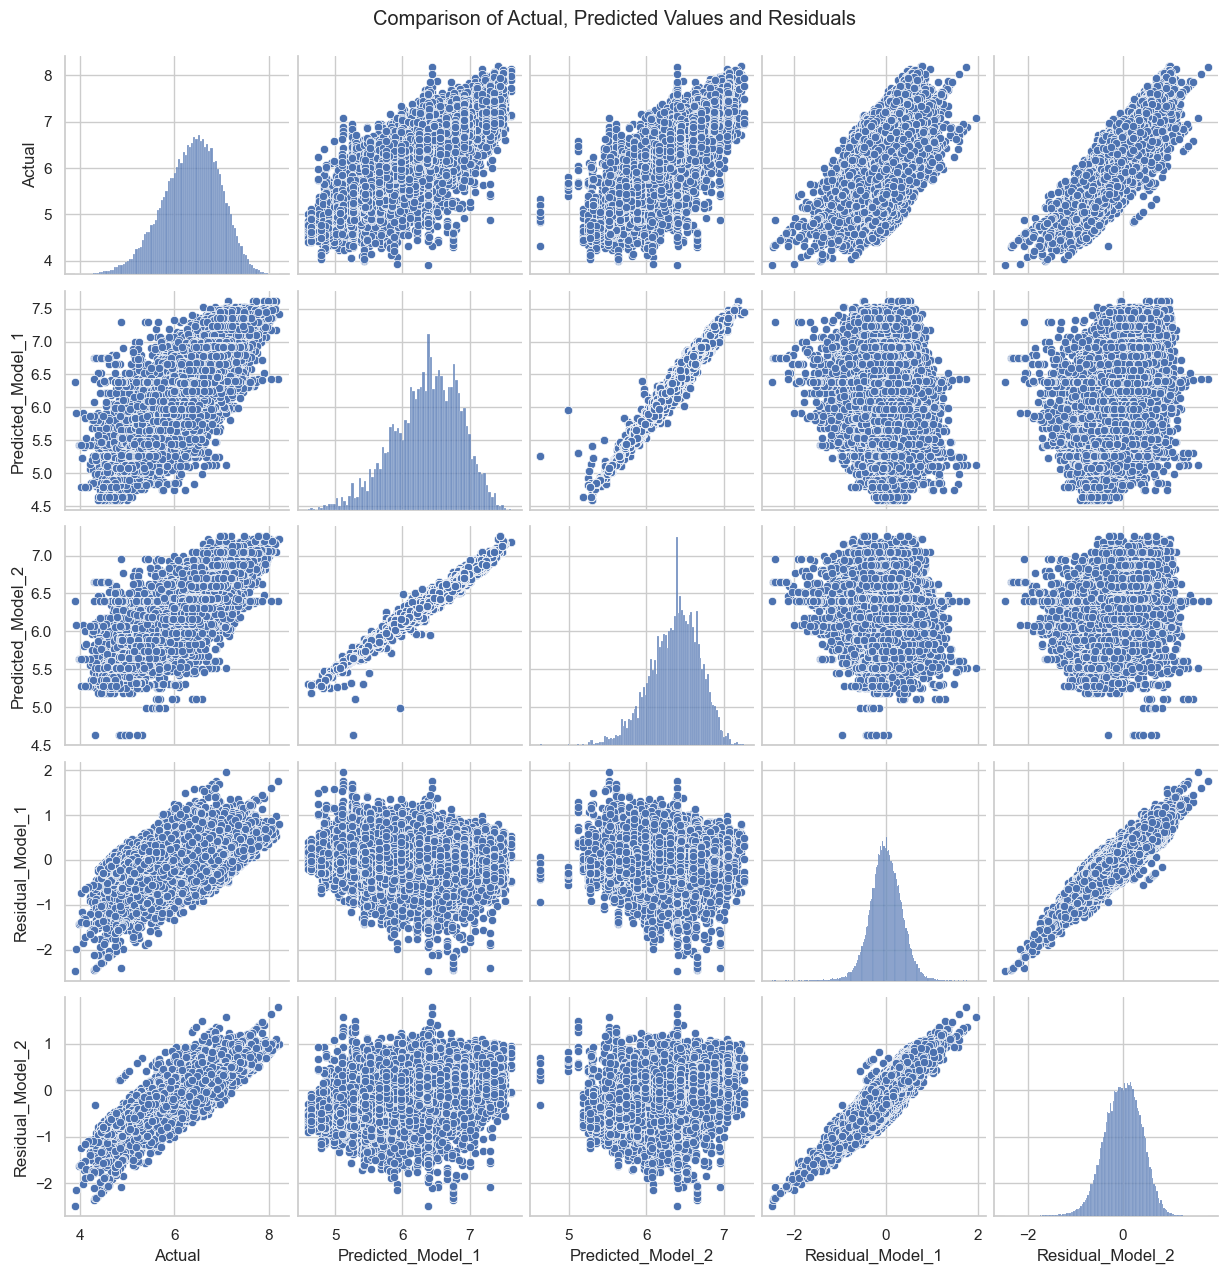

In [55]:
# Create a comparison dataframe for visualization
comparison_df['Residual_Model_1'] = residuals_1
comparison_df['Residual_Model_2'] = residuals_2

sns.pairplot(comparison_df[['Actual', 'Predicted_Model_1', 'Predicted_Model_2', 'Residual_Model_1', 'Residual_Model_2']])
plt.suptitle("Comparison of Actual, Predicted Values and Residuals", y=1.02)
plt.show()


This pairplot visualization compares **actual values**, **predicted values from Model 1 (Gradient Boosting Regressor)**, and **predicted values from Model 2 (LASSO)**, along with their residual distributions. The diagonal histograms show the distributions of each variable, while the scatter plots highlight relationships between them. The **Actual vs. Predicted scatter plots** suggest that Model 1 exhibits a tighter correlation with actual values, indicating better predictive accuracy. Meanwhile, Model 2's scatter plots appear more dispersed, hinting at a weaker fit. The residual plots (showing deviation from actual values) suggest that GBR captures underlying patterns more effectively, while LASSO's residuals are more spread out, reinforcing its lower performance in the previous evaluation metrics.